# Importing Librarries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Data Loading and Exploration | Cleaning

In [2]:
file_name = r"D:\elevvo\titanic.csv"
df = pd.read_csv(file_name)

In [3]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<Axes: >

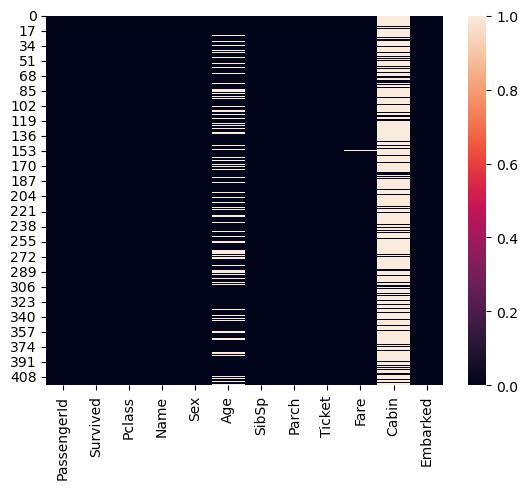

In [7]:
sns.heatmap(df.isnull())

In [ ]:
# Replacing Missing Values

In [8]:
df['Cabin']=df['Cabin'].fillna("Unknown")

In [9]:
df['Cabin']

0      Unknown
1      Unknown
2      Unknown
3      Unknown
4      Unknown
        ...   
413    Unknown
414       C105
415    Unknown
416    Unknown
417    Unknown
Name: Cabin, Length: 418, dtype: object

In [10]:
Age_null_percent=df['Age'].isnull().sum()/len(df)*100

In [11]:
Age_null_percent

20.574162679425836

In [12]:
df.Age=df.Age.fillna(df.Age.median())

In [13]:
df.Age.isnull().sum()

0

In [ ]:
# Grouping and Aggregating and Plotting Results

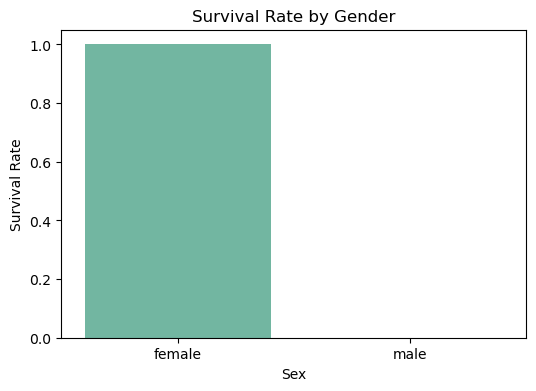

In [14]:
survivors_by_gender = df.groupby('Sex')['Survived'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=survivors_by_gender, x='Sex', y='Survived', palette='Set2')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Gender')
plt.show()

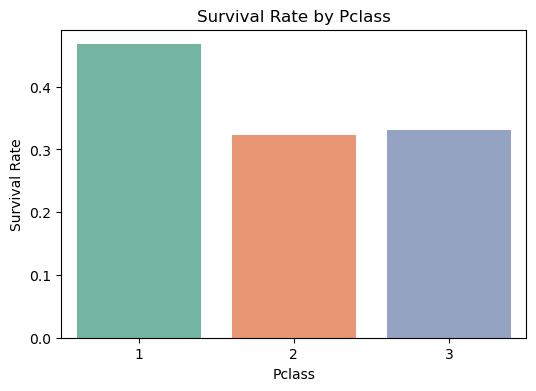

In [15]:
survivors_by_pclass = df.groupby('Pclass')['Survived'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=survivors_by_pclass, x='Pclass', y='Survived', palette='Set2')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Pclass')
plt.show()


In [16]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 80],
    labels=['Child','Teen','Adult','Middle-aged','Senior']
)


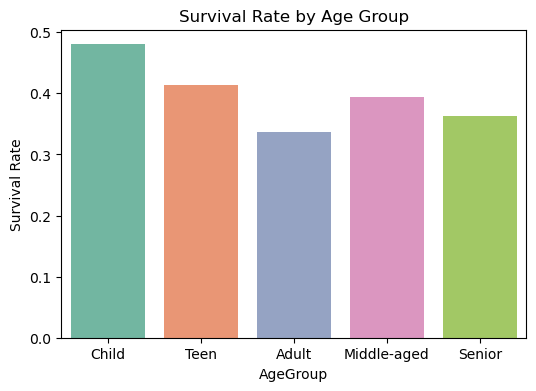

In [17]:
survived_by_age=df.groupby(['AgeGroup'])['Survived'].mean().reset_index().head()
plt.figure(figsize=(6,4))
sns.barplot(data=survived_by_age, x='AgeGroup', y='Survived', palette='Set2')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Age Group')
plt.show()

In [ ]:
# Correlations 

In [18]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,29.599282,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,12.703770,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,35.750000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [19]:
df.corr()

C:\Users\AQSAA\AppData\Local\Temp\ipykernel_3308\1134722465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.023245,-0.026751,-0.031447,0.003818,0.043080,0.008211
Survived,-0.023245,1.000000,-0.108615,0.008035,0.099943,0.159120,0.191514
Pclass,-0.026751,-0.108615,1.000000,-0.467853,0.001087,0.018721,-0.577147
Age,-0.031447,0.008035,-0.467853,1.000000,-0.071197,-0.043731,0.347105
SibSp,0.003818,0.099943,0.001087,-0.071197,1.000000,0.306895,0.171539
Parch,0.043080,0.159120,0.018721,-0.043731,0.306895,1.000000,0.230046
Fare,0.008211,0.191514,-0.577147,0.347105,0.171539,0.230046,1.000000


In [20]:
df.corr()

C:\Users\AQSAA\AppData\Local\Temp\ipykernel_3308\1134722465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.023245,-0.026751,-0.031447,0.003818,0.043080,0.008211
Survived,-0.023245,1.000000,-0.108615,0.008035,0.099943,0.159120,0.191514
Pclass,-0.026751,-0.108615,1.000000,-0.467853,0.001087,0.018721,-0.577147
Age,-0.031447,0.008035,-0.467853,1.000000,-0.071197,-0.043731,0.347105
SibSp,0.003818,0.099943,0.001087,-0.071197,1.000000,0.306895,0.171539
Parch,0.043080,0.159120,0.018721,-0.043731,0.306895,1.000000,0.230046
Fare,0.008211,0.191514,-0.577147,0.347105,0.171539,0.230046,1.000000


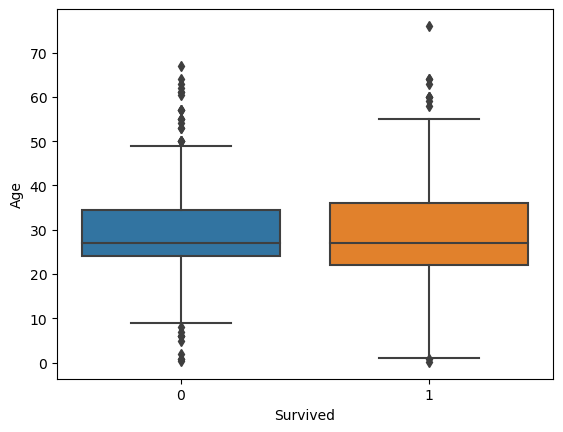

In [21]:
sns.boxplot(data=df, x='Survived', y='Age')
plt.show()


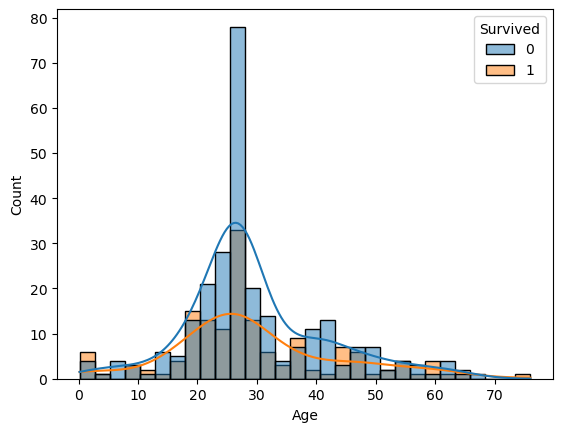

In [22]:
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.show()

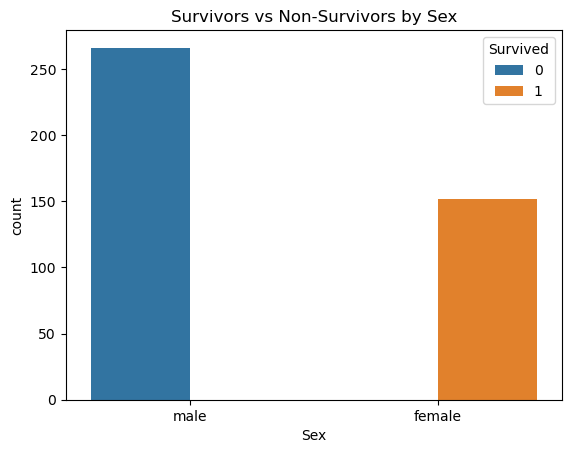

In [24]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survivors vs Non-Survivors by Sex')
plt.show()